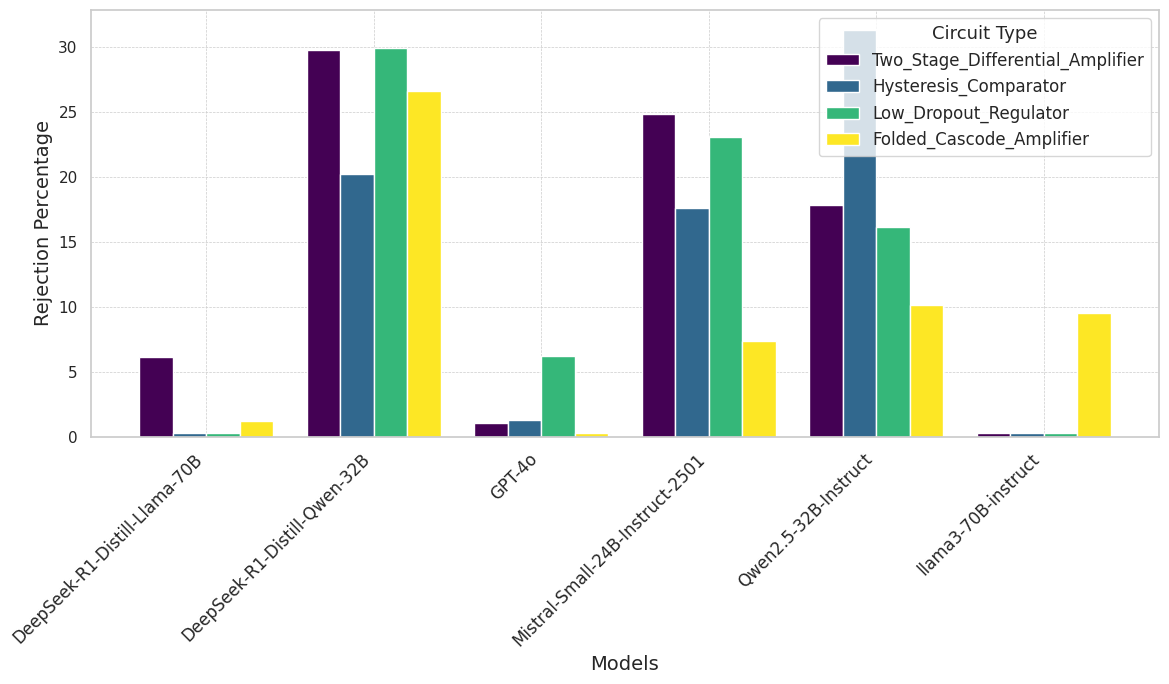

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Use a scientific style for the plot
import seaborn as sns
sns.set(style="whitegrid")

# Your dictionary with rejection scores
data = {
    "DeepSeek-R1-Distill-Llama-70B_Two_Stage_Differential_Amplifier": 0.06183574879227053,
    "DeepSeek-R1-Distill-Llama-70B_Hysteresis_Comparator": 0.0,
    "DeepSeek-R1-Distill-Llama-70B_Low_Dropout_Regulator": 0.0,
    "DeepSeek-R1-Distill-Llama-70B_Folded_Cascode_Amplifier": 0.012658227848101266,
    "DeepSeek-R1-Distill-Qwen-32B_Two_Stage_Differential_Amplifier": 0.29838709677419356,
    "DeepSeek-R1-Distill-Qwen-32B_Hysteresis_Comparator": 0.20238095238095238,
    "DeepSeek-R1-Distill-Qwen-32B_Low_Dropout_Regulator": 0.29958677685950413,
    "DeepSeek-R1-Distill-Qwen-32B_Folded_Cascode_Amplifier": 0.26609195402298846,
    "GPT-4o_Two_Stage_Differential_Amplifier": 0.0107169811320754715,
    "GPT-4o_Hysteresis_Comparator": 0.012711864406779662,
    "GPT-4o_Low_Dropout_Regulator": 0.06272401433691756,
    "GPT-4o_Folded_Cascode_Amplifier": 0.0,
    "llama3-70B-instruct_Two_Stage_Differential_Amplifier": 0.0,
    "llama3-70B-instruct_Hysteresis_Comparator": 0.0,
    "llama3-70B-instruct_Low_Dropout_Regulator": 0.0,
    "llama3-70B-instruct_Folded_Cascode_Amplifier": 0.09539473684210527,
    "Mistral-Small-24B-Instruct-2501_Two_Stage_Differential_Amplifier": 0.2484709480122324,
    "Mistral-Small-24B-Instruct-2501_Hysteresis_Comparator": 0.17670682730923695,
    "Mistral-Small-24B-Instruct-2501_Low_Dropout_Regulator": 0.23076923076923078,
    "Mistral-Small-24B-Instruct-2501_Folded_Cascode_Amplifier": 0.07391304347826087,
    "Qwen2.5-32B-Instruct_Two_Stage_Differential_Amplifier": 0.17878787878787877,
    "Qwen2.5-32B-Instruct_Hysteresis_Comparator": 0.3131868131868132,
    "Qwen2.5-32B-Instruct_Low_Dropout_Regulator": 0.16196236559139784,
    "Qwen2.5-32B-Instruct_Folded_Cascode_Amplifier": 0.10168195718654433
}

# Define the list of circuit types (expected suffixes in the keys)
circuits = [
    "Two_Stage_Differential_Amplifier",
    "Hysteresis_Comparator",
    "Low_Dropout_Regulator",
    "Folded_Cascode_Amplifier"
]

# Parse the dictionary to group rejection scores by model and by circuit
models = {}
for key, score in data.items():
    # Identify which circuit the key corresponds to
    for circuit in circuits:
        if key.endswith(circuit):
            # Remove the trailing underscore and circuit part to obtain the model name
            model_name = key[: -len(circuit) - 1]
            if model_name not in models:
                models[model_name] = {}
            models[model_name][circuit] = score if score >= 0.002 else 0.003
            break

# Get a sorted list of unique model names to display on the x-axis
model_names = sorted(models.keys())

# Build a dictionary of rejection scores for each circuit organized by model order.
scores = {}
for circuit in circuits:
    # For each model, get the score for this circuit (defaulting to 0 if not found)
    scores[circuit] = [models[model].get(circuit, 0)*100 for model in model_names]

# Set up the grouped bar chart parameters
N = len(model_names)
ind = np.arange(N)  # x locations for each group (model)
width = 0.20        # width of each individual bar

# Initialize the figure and axes
fig, ax = plt.subplots(figsize=(12, 7))

# Use a colormap for an elegant scientific color scheme
colors = plt.cm.viridis(np.linspace(0, 1, len(circuits)))

# Plot bars for each circuit type with an appropriate offset for grouping
for i, circuit in enumerate(circuits):
    offset = (i - (len(circuits) - 1) / 2) * width  # centering the groups
    ax.bar(ind + offset, scores[circuit], width, label=circuit, color=colors[i])

# Customize the plot: set labels, title, and x-tick labels
ax.set_xticks(ind)
ax.set_xticklabels(model_names, rotation=45, ha="right", fontsize=12)
ax.set_xlabel("Models", fontsize=14)
ax.set_ylabel("Rejection Percentage", fontsize=14)
# ax.set_title("Rejection Scores per Model and Circuit", fontsize=16)

# Add a legend with a title
ax.legend(title="Circuit Type", fontsize=12, title_fontsize=13)

# Enable grid lines for enhanced clarity
ax.grid(True, which="both", linestyle='--', linewidth=0.5)

# Adjust layout for neat spacing
plt.tight_layout()

# Display the plot
plt.show()


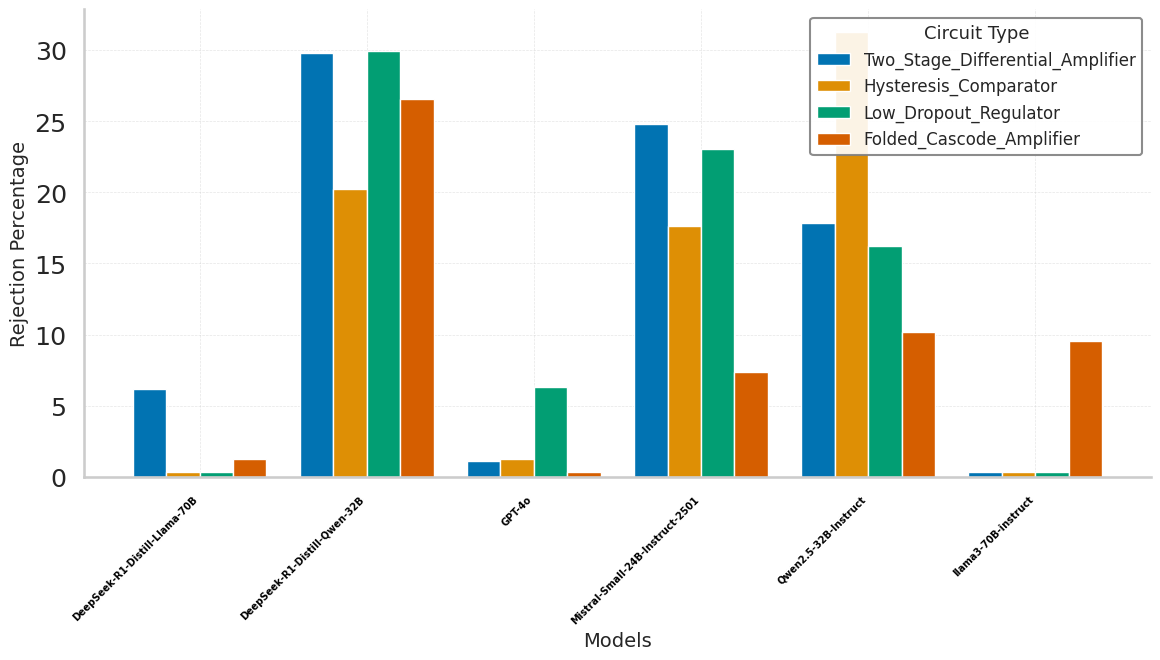

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Set an accessible, elegant theme & palette
sns.set_theme(
    style="whitegrid",            # subtle grid behind data :contentReference[oaicite:6]{index=6}
    palette="colorblind",         # muted, high‑contrast qualitative palette :contentReference[oaicite:7]{index=7}
    context="talk",               # slightly larger fonts for readability :contentReference[oaicite:8]{index=8}
    font_scale=1.1
)

# 2) Original data parsing code (unchanged)
data = {
    "DeepSeek-R1-Distill-Llama-70B_Two_Stage_Differential_Amplifier": 0.06183574879227053,
    "DeepSeek-R1-Distill-Llama-70B_Hysteresis_Comparator": 0.0,
    "DeepSeek-R1-Distill-Llama-70B_Low_Dropout_Regulator": 0.0,
    "DeepSeek-R1-Distill-Llama-70B_Folded_Cascode_Amplifier": 0.012658227848101266,
    "DeepSeek-R1-Distill-Qwen-32B_Two_Stage_Differential_Amplifier": 0.29838709677419356,
    "DeepSeek-R1-Distill-Qwen-32B_Hysteresis_Comparator": 0.20238095238095238,
    "DeepSeek-R1-Distill-Qwen-32B_Low_Dropout_Regulator": 0.29958677685950413,
    "DeepSeek-R1-Distill-Qwen-32B_Folded_Cascode_Amplifier": 0.26609195402298846,
    "GPT-4o_Two_Stage_Differential_Amplifier": 0.0107169811320754715,
    "GPT-4o_Hysteresis_Comparator": 0.012711864406779662,
    "GPT-4o_Low_Dropout_Regulator": 0.06272401433691756,
    "GPT-4o_Folded_Cascode_Amplifier": 0.0,
    "llama3-70B-instruct_Two_Stage_Differential_Amplifier": 0.0,
    "llama3-70B-instruct_Hysteresis_Comparator": 0.0,
    "llama3-70B-instruct_Low_Dropout_Regulator": 0.0,
    "llama3-70B-instruct_Folded_Cascode_Amplifier": 0.09539473684210527,
    "Mistral-Small-24B-Instruct-2501_Two_Stage_Differential_Amplifier": 0.2484709480122324,
    "Mistral-Small-24B-Instruct-2501_Hysteresis_Comparator": 0.17670682730923695,
    "Mistral-Small-24B-Instruct-2501_Low_Dropout_Regulator": 0.23076923076923078,
    "Mistral-Small-24B-Instruct-2501_Folded_Cascode_Amplifier": 0.07391304347826087,
    "Qwen2.5-32B-Instruct_Two_Stage_Differential_Amplifier": 0.17878787878787877,
    "Qwen2.5-32B-Instruct_Hysteresis_Comparator": 0.3131868131868132,
    "Qwen2.5-32B-Instruct_Low_Dropout_Regulator": 0.16196236559139784,
    "Qwen2.5-32B-Instruct_Folded_Cascode_Amplifier": 0.10168195718654433
}
circuits = [
    "Two_Stage_Differential_Amplifier",
    "Hysteresis_Comparator",
    "Low_Dropout_Regulator",
    "Folded_Cascode_Amplifier"
]
models = {}
for key, score in data.items():
    for circuit in circuits:
        if key.endswith(circuit):
            model = key[: -len(circuit) - 1]
            models.setdefault(model, {})[circuit] = max(score, 0.003)
            break
model_names = sorted(models.keys())
scores = {
    circuit: [models[m].get(circuit, 0)*100 for m in model_names]
    for circuit in circuits
}

# 3) Plot setup
N = len(model_names)
ind = np.arange(N)
width = 0.20
fig, ax = plt.subplots(figsize=(12, 7))

# 4) Choose the same color palette for bars
colors = sns.color_palette("colorblind", len(circuits))  # :contentReference[oaicite:9]{index=9}

# 5) Draw bars with white edges for clarity
bars = []
for i, circuit in enumerate(circuits):
    offset = (i - (len(circuits)-1)/2) * width
    bar = ax.bar(
        ind + offset, scores[circuit], width,
        label=circuit,
        color=colors[i],
        edgecolor="white",         # crisp separation :contentReference[oaicite:10]{index=10}
        linewidth=1
    )
    bars.append(bar)

# 6) Add value labels on top of each bar
# for bar in bars:
#     ax.bar_label(bar, fmt="%.1f", label_type="edge", padding=2)  # :contentReference[oaicite:11]{index=11}

# 7) Styling enhancements
ax.set_xticks(ind)
ax.set_xticklabels(model_names, rotation=45, ha="right", fontsize=7, color = 'black', fontweight = 'bold')
ax.set_xlabel("Models", fontsize=14)
ax.set_ylabel("Rejection Percentage", fontsize=14)

# Bring grid behind bars, soften its appearance
ax.set_axisbelow(True)
ax.grid(
    True, which="major",
    linestyle="--", linewidth=0.5, alpha=0.5  # lighter dash :contentReference[oaicite:12]{index=12}
)

# Enable minor ticks for subtle reference lines
ax.minorticks_on()
ax.tick_params(which="minor", length=4)#, alpha=0.6)  # :contentReference[oaicite:13]{index=13}

# Remove top/right spines for a cleaner look
sns.despine(ax=ax, top=True, right=True)  # :contentReference[oaicite:14]{index=14}

# Legend styling
leg = ax.legend(title="Circuit Type", fontsize=12, title_fontsize=13, framealpha=0.9)
leg.get_frame().set_edgecolor("gray")

plt.tight_layout()
plt.savefig("results/fig_rejection_scores.pdf", dpi=300, bbox_inches='tight')  # Save the figure


In [2]:
! pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 18.7 MB/s eta 0:00:00
